C:\Users\ygunj\AppData\Local\Temp\ipykernel_8680\2139575642.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


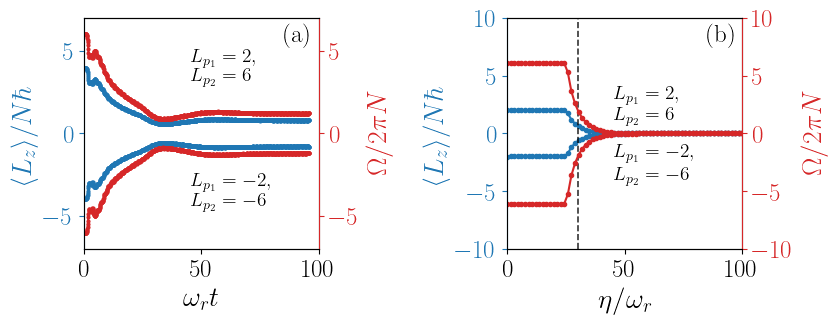

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# LOAD DATA
# ==================================================
data = np.load(r"Figure_11_data.npz")

t_plus  = data['t_plus']
t_minus = data['t_minus']

Lz_plus_t  = data['Lz_plus_t']
Lz_minus_t = data['Lz_minus_t']

Omega_plus_t  = data['Omega_plus_t']
Omega_minus_t = data['Omega_minus_t']

eta_vals = data['eta_vals']

Lz_plus  = data['Lz_plus']
Lz_minus = data['Lz_minus']

Omega_plus  = data['Omega_plus']
Omega_minus = data['Omega_minus']

omega_r = data['omega_r']
hbar    = data['hbar']


# ==================================================
# PRA STYLE
# ==================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 13,
})

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3), gridspec_kw={'wspace': 0.8})


def add_panel_label(ax, label, x=-0.30, y=0.99):
    ax.text(x, y, label,
            transform=ax.transAxes,
            fontsize=18,
            va='top', ha='left')


# ==================================================
# (a) TIME DYNAMICS
# ==================================================
axL = axes[0]
axR = axL.twinx()

# ---- Lz (blue) ----
axL.plot(t_plus * omega_r, Lz_plus_t / hbar,
         'o-', markersize=2, color='tab:blue')

axL.plot(t_minus * omega_r, Lz_minus_t / hbar,
         'o-', markersize=2, color='tab:blue')

# ---- Omega (red) ----
axR.plot(t_plus * omega_r, Omega_plus_t / (2*np.pi),
         'o-', markersize=2, color='tab:red')

axR.plot(t_minus * omega_r, Omega_minus_t / (2*np.pi),
         'o-', markersize=2, color='tab:red')


axL.set_xlabel(r'$\omega_r t$')
axL.set_ylabel(r'$\langle L_z\rangle/ N\hbar$', color='tab:blue')
axR.set_ylabel(r'$\Omega/2\pi N$', color='tab:red')

axL.tick_params(axis='y', colors='tab:blue')
axR.tick_params(axis='y', colors='tab:red')

axL.spines['left'].set_color('tab:blue')
axR.spines['right'].set_color('tab:red')

axL.set_xlim([0, 100])
axL.set_ylim([-7, 7])
axR.set_ylim([-7, 7])


# ---- annotations ----
axL.text(45, 1.1*np.max(Lz_plus_t/hbar),
         r'$L_{p_1}= 2,$', fontsize=14)
axL.text(45, 0.8*np.max(Lz_plus_t/hbar),
         r'$L_{p_2}= 6$', fontsize=14)

axL.text(45, 0.8*np.min(Lz_minus_t/hbar),
         r'$L_{p_1}= -2,$', fontsize=14)
axL.text(45, 1.1*np.min(Lz_minus_t/hbar),
         r'$L_{p_2}= -6$', fontsize=14)


add_panel_label(axL, '(a)', x=0.85, y=0.98)


# ==================================================
# (b) STEADY STATE VS ETA
# ==================================================
axL2 = axes[1]
axR2 = axL2.twinx()

# ---- Lz steady state ----
axL2.plot(eta_vals / omega_r, Lz_plus / hbar,
          'o-', markersize=3, color='tab:blue')

axL2.plot(eta_vals / omega_r, Lz_minus / hbar,
          'o-', markersize=3, color='tab:blue')

# ---- Omega steady state ----
axR2.plot(eta_vals / omega_r, Omega_plus / (2*np.pi),
          'o-', markersize=3, color='tab:red')

axR2.plot(eta_vals / omega_r, Omega_minus / (2*np.pi),
          'o-', markersize=3, color='tab:red')


# vertical line
axL2.axvline(x=30, color='black', linestyle='--',
             linewidth=1.2, alpha=0.8)


axL2.set_xlabel(r'$\eta/\omega_r$')
axL2.set_ylabel(r'$\langle L_z\rangle/N\hbar$', color='tab:blue')
axR2.set_ylabel(r'$\Omega/2\pi N$', color='tab:red')

axL2.tick_params(axis='y', colors='tab:blue')
axR2.tick_params(axis='y', colors='tab:red')

axL2.spines['left'].set_color('tab:blue')
axR2.spines['right'].set_color('tab:red')

axL2.set_xlim([0, 100])
axL2.set_ylim([-10, 10])
axR2.set_ylim([-10, 10])


# ---- annotations ----
axL2.text(45, 1.5*np.max(Lz_plus/hbar),
          r'$L_{p_1}= 2,$', fontsize=14)
axL2.text(45, 0.6*np.max(Lz_plus/hbar),
          r'$L_{p_2}= 6$', fontsize=14)

axL2.text(45, 1*np.min(Lz_minus/hbar),
          r'$L_{p_1}= -2,$', fontsize=14)
axL2.text(45, 2*np.min(Lz_minus/hbar),
          r'$L_{p_2}= -6$', fontsize=14)


add_panel_label(axL2, '(b)', x=0.85, y=0.98)


# ==================================================
plt.tight_layout()
plt.show()